In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *

In [2]:
import os
import sys
sys.path.append(os.path.abspath("conditional-flow-matching"))
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

In [3]:
import random
import umap
from models.modules import *

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
from scripts.run_model import *

In [6]:
from mpl_toolkits.mplot3d import Axes3D

In [7]:
%reload_ext autoreload
%autoreload 2

In [8]:
############################################################

In [9]:
from torchdyn.datasets import generate_moons

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

In [10]:
def sample_torus_piece(size, i, sigma=0.05):

    c = 3
    a = 0.8

    def f(u,v):
        x = (c + a * np.cos(v)) * np.cos(u)
        y = (c + a * np.cos(v)) * np.sin(u)
        z = a * np.sin(v)
        return (x, y, z)

    u = np.pi * np.random.uniform(size=size) + (np.pi if i == 1 else 0)
    v = 2 * np.pi * np.random.uniform(size=size)

    x = np.stack(f(u, v), axis = 1)    
    ep = sigma * np.random.normal(size=(size, 3))
    return x + ep

In [11]:
def process_fake_time_data():
    size = 5000

    x0 = sample_torus_piece(size, 0)
    x1 = sample_torus_piece(size, 1)
    x = np.concatenate([x0, x1], axis = 0)
    adata = ad.AnnData(x)
    adata.obs['timepoint'] = pd.Categorical([0] * size + [1] * size)
    adata.obs['gene_target'] = pd.Categorical(["ctrl-inj"] * (2 * size))
    
    adata.obsm['X_pca'] = adata.X
    adata.varm['PCs'] = np.zeros((3, 3))

    return adata, ['ctrl-inj']

In [12]:
def visualize_samples(samples):

    m = torch.max(torch.abs(samples)).item()
    m += 1
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], c='blue', s=2, alpha=0.2)
    ax.set_aspect('equal')
    plt.show()
    plt.close()

In [13]:
adata, values = process_fake_time_data()
conditions, dataset = extract_dataset(adata, values)

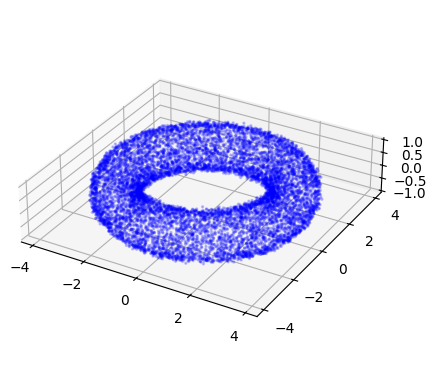

In [14]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_samples(samples)

In [15]:
############################################################

In [16]:
config = Config(
    {        
        "model_class": "metricflow",
        "score_max_epochs": 30,
        "energy_max_epochs": 30,
        "embed_max_epochs": 2000,
        "flow_max_epochs": 2000,
        "lr": 1e-4,
        "dropout": 0.0,
        "pc_dim": 3,
        "cond_dim": 3,
        "hidden_dim": 256,
        "batch_size": 512,
        "num_freq": 32,
        "num_layers": 3,
        "control_only": True,
        "force_cpu": False,
        "constrain": False,
        "gradient_clip_val": 0,
        "loader_batch_size": 2,
        "accumulate_grad_batches": 1,
        "warmup_steps": 0,
        "ema_decay": None,
        "score_sigma": [0.01, 0.05, 0.1, 0.2, 0.3],
        "energy_sigma": [0.0, 0.01, 0.1, 0.3],
        
        "geo_sigma": 0.2,

        "latent_dim": 100,

        "skip": True,
        "rescale": 0.5,

        "low_q": .05,
        "high_q": 1.0, #USED IN INTERPOLATION

        "alpha": 0.5,
        "beta": 1.0,
        "gamma": 1.0,
        "margin": 2.0,

        "sigma": 0.1,
        "cfg_p_u": 0.0,
        "cfg_w": 1.0,
    }
)

project = "fm-ipynb"

In [17]:
score_model, energy_model, embed_model, flow_model = run_full_model(config, project, adata, values, conditions, dataset)

wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 |

epoch,▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▇▇▇█████
train_loss,▅▆▃▇▄▇▇▄▇▇▆▄▅▄▃▄▆█▄▄▅▇▄▆▄▄▇▆▃▅▄▅▄▅▄▂▃▄▄▁
trainer/global_step,▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
epoch,29
train_loss,50.78498
trainer/global_step,599


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type           | Params | Mode 
------------------------------------------------------
0 | score_net  | SimpleDenseNet | 134 K  | train
1 | energy_net | SimpleDenseNet | 134 K  | train
------------------------------------------------------
134 K     Trainable params
134 K     Non-trainable params
269 K     Total params
1.079     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode
/home/azweig/miniconda3/e

epoch,▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇█
train_loss,█▇▅▅▅▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇█████
epoch,29
train_loss,0.05281
trainer/global_step,599


-4.442018508911133 -2.628422260284424


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type           | Params | Mode 
------------------------------------------------------
0 | embed_net  | SimpleDenseNet | 159 K  | train
1 | geo_net    | SinNet         | 152 K  | train
2 | energy_net | SimpleDenseNet | 134 K  | train
3 | score_net  | SimpleDenseNet | 134 K  | train
------------------------------------------------------
312 K     Trainable params
269 K     Non-trainable params
582 K     Total params
2.330     Total estimated model params 

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇█████
train_loss,█▄▄▄▃▄▄▂▃▃▃▂▃▃▃▂▂▃▃▃▃▂▃▃▂▁▂▁▁▂▁▂▁▂▂▃▂▁▁▂
trainer/global_step,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
epoch,1999
train_loss,17.32482
trainer/global_step,1999


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | flow_net  | SinNet         | 152 K  | train
1 | embed_net | SimpleDenseNet | 159 K  | train
2 | geo_net   | SinNet         | 152 K  | train
3 | score_net | SimpleDenseNet | 134 K  | train
-----------------------------------------------------
304 K     Trainable params
294 K     Non-trainable params
599 K     Total params
2.399     Total estimated model params size (M

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇█
train_loss,█▄▅▄▃▃▂▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇█
epoch,1999
train_loss,0.29416
trainer/global_step,1999


In [18]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(score_model)
remove_all_forward_hooks(energy_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

In [19]:
def visualize(model, samples, steps=10, arrow_scale=0.5):
    m = torch.max(torch.abs(samples)) + 1
    xs = torch.linspace(-m, m, steps)
    ys = torch.linspace(-m, m, steps)
    zs = torch.linspace(-m, m, steps)
    x, y, z = torch.meshgrid(xs, ys, zs, indexing='ij')  # ensure proper indexing
    grid_points = torch.stack([x, y, z], dim=-1).reshape(-1, 3)

    # Compute score field
    with torch.no_grad():
        vectors = model(grid_points)

    # Optionally normalize vectors for better visualization
    norms = torch.norm(vectors, dim=1, keepdim=True) + 1e-8
    vectors_normalized = vectors / norms

    # Subsample to avoid clutter
    stride = max(1, len(grid_points) // 500)  # show ~500 arrows max
    w = grid_points[::stride]
    v = vectors_normalized[::stride]

    # Plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.quiver(w[:, 0], w[:, 1], w[:, 2],
              v[:, 0], v[:, 1], v[:, 2],
              length=arrow_scale, normalize=True, color='orange', alpha=0.7)

    ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2],
               color='blue', alpha=0.3, s=5)

    ax.set_xlim(-m, m)
    ax.set_ylim(-m, m)
    ax.set_zlim(-m, m)
    ax.set_box_aspect([1, 1, 1])
    ax.set_title("Score Matching Vector Field")
    plt.tight_layout()
    plt.show()

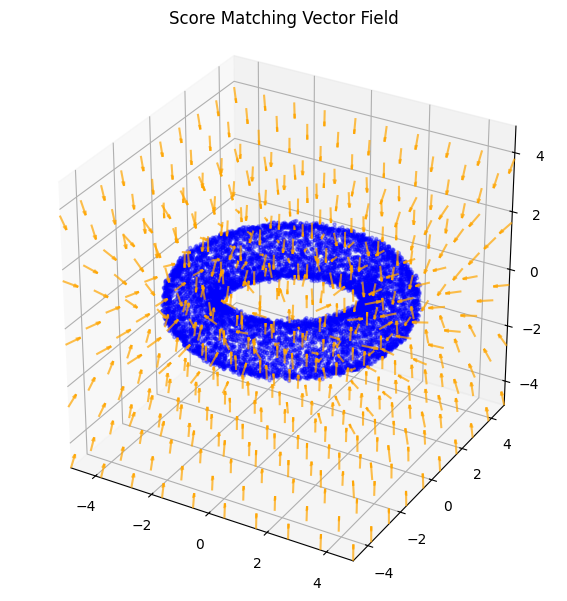

In [20]:
#SCORE VALIDATION
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize(score_model.score_net, samples)

In [21]:
def visualize_energy_vectors(energy_model, samples, steps=10, arrow_scale=0.5):
    m = torch.max(torch.abs(samples)) + 1
    xs = torch.linspace(-m, m, steps)
    ys = torch.linspace(-m, m, steps)
    zs = torch.linspace(-m, m, steps)
    x, y, z = torch.meshgrid(xs, ys, zs, indexing='ij')  # ensure proper indexing
    grid_points = torch.stack([x, y, z], dim=-1).reshape(-1, 3)

    # Compute score field
    with torch.no_grad():
        vectors = energy_model._energy_grad(grid_points).detach()

    # Optionally normalize vectors for better visualization
    norms = torch.norm(vectors, dim=1, keepdim=True) + 1e-8
    vectors_normalized = vectors / norms

    # Subsample to avoid clutter
    stride = max(1, len(grid_points) // 500)  # show ~500 arrows max
    w = grid_points[::stride]
    v = vectors_normalized[::stride]

    # Plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.quiver(w[:, 0], w[:, 1], w[:, 2],
              v[:, 0], v[:, 1], v[:, 2],
              length=arrow_scale, normalize=True, color='orange', alpha=0.7)

    ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2],
               color='blue', alpha=0.3, s=5)

    ax.set_xlim(-m, m)
    ax.set_ylim(-m, m)
    ax.set_zlim(-m, m)
    ax.set_box_aspect([1, 1, 1])
    ax.set_title("Energy Matching Vector Field")
    plt.tight_layout()
    plt.show()

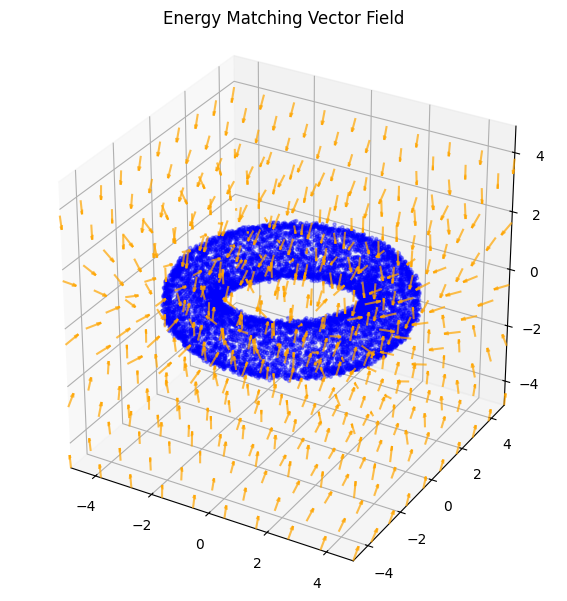

In [22]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_energy_vectors(energy_model, samples)

In [23]:
from torch.utils.data import TensorDataset, Sampler, DataLoader
from utils.dataset import *

train_dataset = ShufflingDataset(dataset, 5, conditions)
train_dataloader = DataLoader(train_dataset, batch_size = config.loader_batch_size, shuffle=True)

In [28]:
#EMBED VALIDATION
for batch in train_dataloader:
    
    paths = embed_model.sample_geodesic(batch, points=1000, ot_sample=False)
    
    break

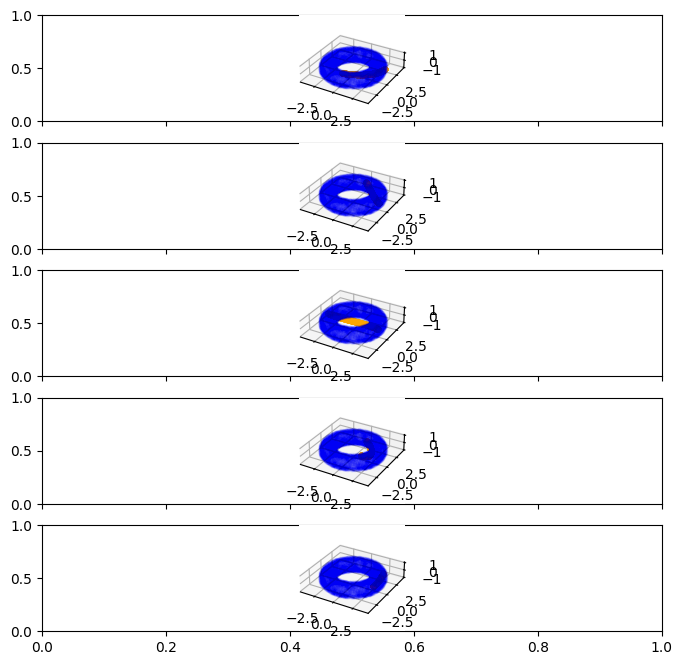

In [29]:
#GEO VALIDATION
fig, ax = plt.subplots(5, figsize=(8, 8), sharex=True, sharey=True)

for i in range(5):
    ax[i] = fig.add_subplot(5, 1, i + 1, projection='3d')

for i in range(5):
    traj = paths[:,i]
    ax[i].scatter(samples[:, 0], samples[:, 1], samples[:, 2],
               color='blue', alpha=0.02, s=5)
    ax[i].plot(traj[:, 0], traj[:, 1], traj[:, 2], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
    ax[i].set(adjustable='box', aspect='equal')
plt.show()

In [26]:
#FLOW VALIDATION

num_samples = 1024
steps = 500
value = 'ctrl-inj'
c = conditions[value]
c = c.unsqueeze(0).repeat(num_samples, 1)

In [27]:
# x = sample_quarter(num_samples, 0)
t = 0
t += np.random.uniform(-0.3, 0.3, size=num_samples)
x = np.stack((t, np.sin(t)), axis = 1)
x += 0.05 * np.random.normal(size=(num_samples, 2))
traj = flow_model.sample_traj(x, c, 0, 4, num_samples, steps=steps)
plot_trajectories(traj.cpu().numpy())

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1024x69 and 70x256)

In [ ]:
# x = sample_quarter(num_samples, 1)
t = 1
t += np.random.uniform(-0.3, 0.3, size=num_samples)
x = np.stack((t, np.sin(t)), axis = 1)
x += 0.05 * np.random.normal(size=(num_samples, 2))
traj = flow_model.sample_traj(x, c, 1, 3, num_samples, steps=steps)
plot_trajectories(traj.cpu().numpy())